# Implementing Long Short Term Memory with Keras

## Loading and Visualizing Data

In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow kagglehub


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy
import pandas as pd 
import matplotlib.pyplot as plt
import math
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andreazzini/international-airline-passengers")

print("Path to dataset files:", path)

c:\Users\mithsuka.dikkumbura\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\mithsuka.dikkumbura\.cache\kagglehub\datasets\andreazzini\international-airline-passengers\versions\1


In [4]:
data = pd.read_csv(path+'/international-airline-passengers.csv',skipfooter=5, engine='python') # The last 5 data was contaminated
data.head()

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


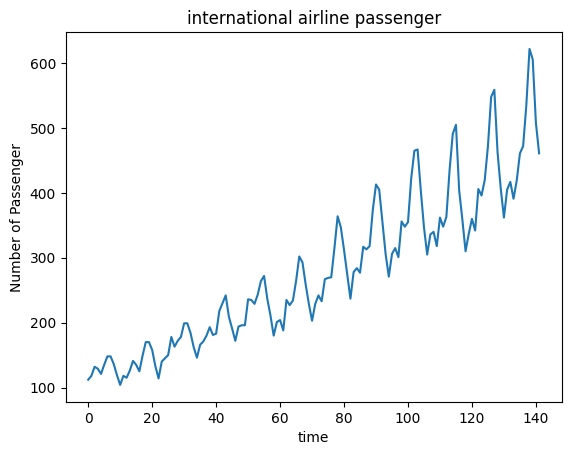

In [5]:
dataset = data.iloc[:,1].values
plt.plot(dataset)
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("international airline passenger")
plt.show()

## Preprocessing Data
Reshape

Change type

Scaling

Train test split

Create dataset

In [6]:
# LSTM expects 2D or 3D input
dataset = dataset.reshape(-1,1) # outputs a column with many rows
dataset = dataset.astype("float32")
dataset.shape

(142, 1)

In [7]:
# scaling 
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [8]:
train_size = int(len(dataset) * 0.50)
test_size = len(dataset) - train_size
train = dataset[0:train_size,:]
test = dataset[train_size:len(dataset),:]
print("train size: {}, test size: {} ".format(len(train), len(test)))

train size: 71, test size: 71 


In [9]:
time_stemp = 10 # Use the previous 10 time steps to predict the next value

dataX = []
dataY = []
for i in range(len(train)-time_stemp-1):
    a = train[i:(i+time_stemp), 0]
    dataX.append(a)
    dataY.append(train[i + time_stemp, 0])
trainX = numpy.array(dataX)
trainY = numpy.array(dataY)  

In [10]:
dataX = []
dataY = []
for i in range(len(test)-time_stemp-1):
    a = test[i:(i+time_stemp), 0]
    dataX.append(a)
    dataY.append(test[i + time_stemp, 0])
testX = numpy.array(dataX)
testY = numpy.array(dataY) 

In [11]:
trainX.shape

(60, 10)

In [12]:
# LTSM expects shape: (samples, timesteps, features)
trainX = numpy.reshape(trainX, (trainX.shape[0], time_stemp, 1))
testX = numpy.reshape(testX, (testX.shape[0], time_stemp, 1))
"Here: samples = number of training examples. timesteps = 10. features = 1. So each sample is treated as one time step with 10 features"

'Here: samples = number of training examples. timesteps = 10. features = 1. So each sample is treated as one time step with 10 features'

## Create LSTM Model

In [13]:
## Model's layer breakdown:
# Input layer: shape (1, 10)
# LSTM layer:
#   10 memory cells (neurons)
#   Learns temporal dependencies
# Dense layer:
#   Outputs a single value (next passenger count)

model = Sequential()
model.add(Input(shape=(time_stemp, 1))) 
model.add(LSTM(10)) 
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=50, batch_size=1)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0279
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079  
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0068 
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059  
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032
Epoch 16/50
60

## Predictions and Visualising LSTM Model

In [14]:
# Predictions are scaled in 0–1 range:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# invert predictions - back to actual passenger numbers
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

# calculate root mean squared error to measure average prediction error (lower is better)
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Train Score: 25.20 RMSE
Test Score: 55.98 RMSE


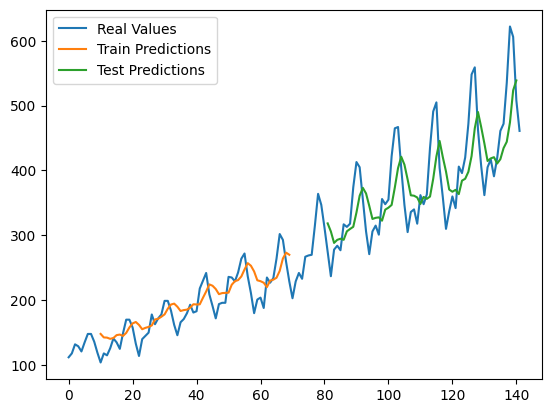

In [15]:
# shifting train
trainPredictPlot = numpy.empty_like(dataset)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[time_stemp:len(trainPredict)+time_stemp, :] = trainPredict

# shifting test predictions for plotting
testPredictPlot = numpy.empty_like(dataset)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(trainPredict)+(time_stemp*2)+1:len(dataset)-1, :] = testPredict

# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset), label = "Real Values")
plt.plot(trainPredictPlot, label = "Train Predictions")
plt.plot(testPredictPlot, label = "Test Predictions")
plt.legend()
plt.show()

## Assignment

 
1) Examin the original notebook. Identify why timesteps=1 is unusual and explain how to choose time_stemp properly! 
2) Try different window sizes (e.g., 5, 15) and explain impact.
3) Why normalization matters for neural networks?
4) Experiment with number of neurons (5, 10, 20) and activation functions. Explain impact!
5) Train with different batch sizes and epochs. Explain impact!
6) If there is a different evaluation metric, try that!

Advanced:

7) Predict multiple months ahead (e.g., next 3 months) instead of one.
8) Improve performance with Dropout or multiple LSTM layers.
9) Predict next 12 months and plot the forecast.

#### License
This Notebook has been released under the Apache 2.0 open source license.

https://www.kaggle.com/code/moonglow22/rnn-and-lstm-tutorial-for-beginners/notebook

Answers

1.

The timesteps=1 because this use only 1 previous month to predict next month. Time pattern is like trend + seasonaly.

To choose time_stemp
    1. First start with values like 3,6,12(monthly data offen has 12 in seasonali)
    2. Then test values like 5,8,10,15
    3. Finaly pich one with the lowest error.

2.

In [16]:
for ws in [5, 15]:
    dataX = []
    dataY = []
    for i in range(len(train)-ws-1):
        a = train[i:(i+ws), 0]
        dataX.append(a)
        dataY.append(train[i + ws, 0])
    trainX2 = numpy.array(dataX)
    trainY2 = numpy.array(dataY)

    dataX = []
    dataY = []
    for i in range(len(test)-ws-1):
        a = test[i:(i+ws), 0]
        dataX.append(a)
        dataY.append(test[i + ws, 0])
    testX2 = numpy.array(dataX)
    testY2 = numpy.array(dataY)

    trainX2 = numpy.reshape(trainX2, (trainX2.shape[0], ws, 1))
    testX2 = numpy.reshape(testX2, (testX2.shape[0], ws, 1))

    model2 = Sequential()
    model2.add(Input(shape=(ws,1)))
    model2.add(LSTM(10))
    model2.add(Dense(1))
    model2.compile(loss='mean_squared_error', optimizer='adam')

    model2.fit(trainX2, trainY2, epochs=50, batch_size=1, verbose=0)

    testPredict2 = model2.predict(testX2, verbose=0)

    testPredict2 = scaler.inverse_transform(testPredict2)
    testY2 = scaler.inverse_transform([testY2])

    testScore = math.sqrt(mean_squared_error(testY2[0], testPredict2[:,0]))

    print(f"Window Size {ws} -> Test RMSE: {testScore:.2f}")

Window Size 5 -> Test RMSE: 69.25
Window Size 15 -> Test RMSE: 56.17


Smaller window like 5 learns short-term patterns
Larger window like 15 can capture longer patterns but may overfit

3.Normalization is important because Neural networks train better with small numbers. scalling to 1-0 makes training stable and faster

4.

In [19]:
dataX, dataY = [], []
for i in range(len(train)-time_stemp-1):
    dataX.append(train[i:(i+time_stemp), 0])
    dataY.append(train[i + time_stemp, 0])
trainX_q4 = numpy.array(dataX).reshape(-1, time_stemp, 1)
trainY_q4 = numpy.array(dataY)

dataX, dataY = [], []
for i in range(len(test)-time_stemp-1):
    dataX.append(test[i:(i+time_stemp), 0])
    dataY.append(test[i + time_stemp, 0])
testX_q4 = numpy.array(dataX).reshape(-1, time_stemp, 1)
testY_q4 = numpy.array(dataY).reshape(-1, 1)

for neurons in [5, 10, 20]:
    for act in ["tanh", "relu"]:
        m = Sequential()
        m.add(Input(shape=(time_stemp, 1)))
        m.add(LSTM(neurons, activation=act))
        m.add(Dense(1))
        m.compile(loss="mean_squared_error", optimizer="adam")
        m.fit(trainX_q4, trainY_q4, epochs=30, batch_size=1, verbose=0)

        pred = m.predict(testX_q4, verbose=0)

        pred_real = scaler.inverse_transform(pred)
        y_real = scaler.inverse_transform(testY_q4)

        rmse = math.sqrt(mean_squared_error(y_real[:,0], pred_real[:,0]))
        print(f"neurons={neurons}, activation={act} -> Test RMSE: {rmse:.2f}")

neurons=5, activation=tanh -> Test RMSE: 75.22
neurons=5, activation=relu -> Test RMSE: 64.91
neurons=10, activation=tanh -> Test RMSE: 67.08
neurons=10, activation=relu -> Test RMSE: 156.02
neurons=20, activation=tanh -> Test RMSE: 68.41
neurons=20, activation=relu -> Test RMSE: 69.71


If add more neurons model can identify more patterns
Toomany neurons can cause overfitting
tanh is the safest activation for LSTM

5.

In [21]:
dataX, dataY = [], []
for i in range(len(train)-time_stemp-1):
    dataX.append(train[i:(i+time_stemp), 0])
    dataY.append(train[i + time_stemp, 0])
trainX_q5 = numpy.array(dataX).reshape(-1, time_stemp, 1)
trainY_q5 = numpy.array(dataY)

dataX, dataY = [], []
for i in range(len(test)-time_stemp-1):
    dataX.append(test[i:(i+time_stemp), 0])
    dataY.append(test[i + time_stemp, 0])
testX_q5 = numpy.array(dataX).reshape(-1, time_stemp, 1)
testY_q5 = numpy.array(dataY).reshape(-1, 1)

configs = [(1,30), (1,80), (8,50), (32,50)]

for batch, ep in configs:
    model5 = Sequential()
    model5.add(Input(shape=(time_stemp,1)))
    model5.add(LSTM(10))
    model5.add(Dense(1))
    model5.compile(loss='mean_squared_error', optimizer='adam')

    model5.fit(trainX_q5, trainY_q5, epochs=ep, batch_size=batch, verbose=0)

    pred = model5.predict(testX_q5, verbose=0)

    # invert scaling safely
    pred_real = scaler.inverse_transform(pred)
    y_real = scaler.inverse_transform(testY_q5)

    rmse = math.sqrt(mean_squared_error(y_real[:,0], pred_real[:,0]))
    print(f"Batch={batch}, Epochs={ep} -> Test RMSE: {rmse:.2f}")

Batch=1, Epochs=30 -> Test RMSE: 63.88
Batch=1, Epochs=80 -> Test RMSE: 95.15
Batch=8, Epochs=50 -> Test RMSE: 71.29
Batch=32, Epochs=50 -> Test RMSE: 118.91


More epochs means more learning
Too many epochs can cause overfitting
Small batch size often works better for time series

6.

In [23]:
dataX, dataY = [], []
for i in range(len(train)-time_stemp-1):
    dataX.append(train[i:(i+time_stemp), 0])
    dataY.append(train[i + time_stemp, 0])
trainX_q6 = numpy.array(dataX).reshape(-1, time_stemp, 1)
trainY_q6 = numpy.array(dataY)

dataX, dataY = [], []
for i in range(len(test)-time_stemp-1):
    dataX.append(test[i:(i+time_stemp), 0])
    dataY.append(test[i + time_stemp, 0])
testX_q6 = numpy.array(dataX).reshape(-1, time_stemp, 1)
testY_q6 = numpy.array(dataY).reshape(-1, 1)

model6 = Sequential()
model6.add(Input(shape=(time_stemp,1)))
model6.add(LSTM(10))
model6.add(Dense(1))
model6.compile(loss='mean_squared_error', optimizer='adam')
model6.fit(trainX_q6, trainY_q6, epochs=50, batch_size=1, verbose=0)

pred = model6.predict(testX_q6, verbose=0)

pred_real = scaler.inverse_transform(pred)
y_real = scaler.inverse_transform(testY_q6)

# metrics
mae = numpy.mean(numpy.abs(y_real[:,0] - pred_real[:,0]))
mape = numpy.mean(numpy.abs((y_real[:,0] - pred_real[:,0]) / y_real[:,0])) * 100

print("Test MAE:", round(mae, 2))
print("Test MAPE:", round(mape, 2))

Test MAE: 45.98
Test MAPE: 11.04


From MAE mecure average mistake
From MAE mecure average presentage of mistake 

7.

In [24]:
dataX, dataY = [], []
for i in range(len(train)-time_stemp-1):
    dataX.append(train[i:(i+time_stemp), 0])
    dataY.append(train[i + time_stemp, 0])
trainX_q7 = numpy.array(dataX).reshape(-1, time_stemp, 1)
trainY_q7 = numpy.array(dataY)

model7 = Sequential()
model7.add(Input(shape=(time_stemp,1)))
model7.add(LSTM(10))
model7.add(Dense(1))
model7.compile(loss='mean_squared_error', optimizer='adam')
model7.fit(trainX_q7, trainY_q7, epochs=60, batch_size=1, verbose=0)

last_window = dataset[-time_stemp:].copy()
preds_scaled = []

for _ in range(3):
    x = last_window.reshape(1, time_stemp, 1)
    yhat = model7.predict(x, verbose=0)[0,0]
    preds_scaled.append(yhat)
    last_window = numpy.vstack([last_window[1:], [[yhat]]])

preds_scaled = numpy.array(preds_scaled).reshape(-1, 1)
preds_real = scaler.inverse_transform(preds_scaled)

print("Next 3 months prediction:", preds_real.ravel())

Next 3 months prediction: [365.4724  296.5271  248.61226]


First predict a 1 month
Then add that prediction into the input window and repeat to get 3 months
More steps is more chance for error

8.

In [26]:
from keras.layers import Dropout

dataX, dataY = [], []
for i in range(len(train)-time_stemp-1):
    dataX.append(train[i:(i+time_stemp), 0])
    dataY.append(train[i + time_stemp, 0])
trainX_q8 = numpy.array(dataX).reshape(-1, time_stemp, 1)
trainY_q8 = numpy.array(dataY)

dataX, dataY = [], []
for i in range(len(test)-time_stemp-1):
    dataX.append(test[i:(i+time_stemp), 0])
    dataY.append(test[i + time_stemp, 0])
testX_q8 = numpy.array(dataX).reshape(-1, time_stemp, 1)
testY_q8 = numpy.array(dataY).reshape(-1, 1)

mA = Sequential()
mA.add(Input(shape=(time_stemp,1)))
mA.add(LSTM(10))
mA.add(Dense(1))
mA.compile(loss='mean_squared_error', optimizer='adam')
mA.fit(trainX_q8, trainY_q8, epochs=60, batch_size=1, verbose=0)

mB = Sequential()
mB.add(Input(shape=(time_stemp,1)))
mB.add(LSTM(10, return_sequences=True))
mB.add(Dropout(0.2))
mB.add(LSTM(10))
mB.add(Dense(1))
mB.compile(loss='mean_squared_error', optimizer='adam')
mB.fit(trainX_q8, trainY_q8, epochs=60, batch_size=1, verbose=0)

predA = scaler.inverse_transform(mA.predict(testX_q8, verbose=0))
predB = scaler.inverse_transform(mB.predict(testX_q8, verbose=0))
y_real = scaler.inverse_transform(testY_q8)

rmseA = math.sqrt(mean_squared_error(y_real[:,0], predA[:,0]))
rmseB = math.sqrt(mean_squared_error(y_real[:,0], predB[:,0]))

print("Baseline RMSE:", round(rmseA, 2))
print("Stacked+Dropout RMSE:", round(rmseB, 2))

Baseline RMSE: 62.76
Stacked+Dropout RMSE: 113.39


Dropout reduce overfitting
2 LSTM layers can learn more complex patterns
Depends on data size sometimes it overfits

9.

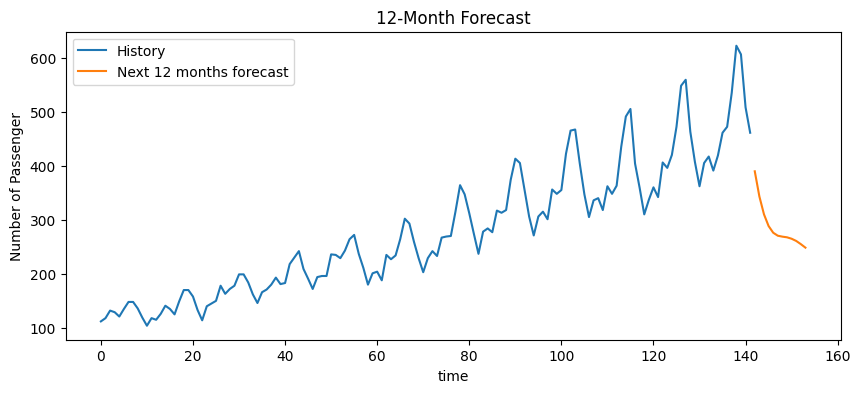

Next 12 months forecast: [389.6821  343.14532 310.06976 288.44235 276.05533 270.51065 268.7776
 267.56317 264.91257 260.82608 254.94264 248.43182]


In [27]:
dataX, dataY = [], []
for i in range(len(train)-time_stemp-1):
    dataX.append(train[i:(i+time_stemp), 0])
    dataY.append(train[i + time_stemp, 0])
trainX_q9 = numpy.array(dataX).reshape(-1, time_stemp, 1)
trainY_q9 = numpy.array(dataY)

model9 = Sequential()
model9.add(Input(shape=(time_stemp,1)))
model9.add(LSTM(10))
model9.add(Dense(1))
model9.compile(loss='mean_squared_error', optimizer='adam')
model9.fit(trainX_q9, trainY_q9, epochs=80, batch_size=1, verbose=0)

last_window = dataset[-time_stemp:].copy()
preds_scaled = []

for _ in range(12):
    x = last_window.reshape(1, time_stemp, 1)
    yhat = model9.predict(x, verbose=0)[0,0]
    preds_scaled.append(yhat)
    last_window = numpy.vstack([last_window[1:], [[yhat]]])

preds_scaled = numpy.array(preds_scaled).reshape(-1, 1)
forecast = scaler.inverse_transform(preds_scaled).ravel()

history = scaler.inverse_transform(dataset).ravel()
x_hist = numpy.arange(len(history))
x_fore = numpy.arange(len(history), len(history)+12)

plt.figure(figsize=(10,4))
plt.plot(x_hist, history, label="History")
plt.plot(x_fore, forecast, label="Next 12 months forecast")
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("12-Month Forecast")
plt.legend()
plt.show()

print("Next 12 months forecast:", forecast)